In [ ]:
# 🛒 Blinkit 360° Intelligence
## Phase 1: Data Loading, Cleaning & Audit
**Author:** Your Name  
**Project:** End-to-end Data Science — Operations & Expansion Analysis  
**Data:** 14 datasets | 250,000+ rows  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Blinkit brand colors
BLINKIT_YELLOW = '#F8D42D'
BLINKIT_BLACK  = '#0C0C0C'
BLINKIT_GREEN  = '#2DD256'

print("✅ All libraries loaded successfully!")

C:\Users\dell\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


✅ All libraries loaded successfully!


In [2]:
# ============================================================
# CELL 2: LOAD ALL DATASETS
# ============================================================
import os

DATA_PATH = "C:\Blinkit 360° Intelligence"

# Load all files
orders       = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\blinkit_orders.csv")
order_items  = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\blinkit_order_items.csv")
customers    = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\blinkit_customers.csv")
delivery     = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\blinkit_delivery_performance.csv")
feedback     = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\blinkit_customer_feedback.csv")
inventory    = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\blinkit_inventory.csv")
inventory_new= pd.read_csv(r"C:\Blinkit 360° Intelligence\data\blinkit_inventoryNew.csv")
marketing    = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\blinkit_marketing_performance.csv")
products     = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\blinkit_products.csv")
grocery      = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\BlinkIT-Grocery-Data.csv")
retail       = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\blinkit_retail.csv", encoding='latin1')
udupi        = pd.read_csv(r"C:\Blinkit 360° Intelligence\data\udupi_market_data.csv")

print("✅ All 12 datasets loaded!")
print(f"\n{'Dataset':<30} {'Rows':>8} {'Columns':>8}")
print("-" * 50)
datasets = {
    'orders': orders, 'order_items': order_items,
    'customers': customers, 'delivery': delivery,
    'feedback': feedback, 'inventory': inventory,
    'inventory_new': inventory_new, 'marketing': marketing,
    'products': products, 'grocery': grocery,
    'retail': retail, 'udupi': udupi
}
for name, df in datasets.items():
    print(f"{name:<30} {df.shape[0]:>8,} {df.shape[1]:>8}")

✅ All 12 datasets loaded!

Dataset                            Rows  Columns
--------------------------------------------------
orders                            5,000       10
order_items                       5,000        4
customers                         2,500       11
delivery                          5,000        8
feedback                          5,000        8
inventory                        75,172        4
inventory_new                    18,105        4
marketing                         5,400       11
products                            268       10
grocery                           8,523       12
retail                          116,554        7
udupi                                14        5


In [3]:
# ============================================================
# CELL 3: DATA QUALITY AUDIT — LIKE A REAL DATA SCIENTIST
# ============================================================
def audit_dataframe(df, name):
    """
    Checks: shape, nulls, duplicates, dtypes
    """
    print(f"\n{'='*60}")
    print(f"📋 AUDIT: {name.upper()}")
    print(f"{'='*60}")
    print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Duplicates   : {df.duplicated().sum():,}")
    print(f"Memory Usage : {df.memory_usage().sum() / 1024:.1f} KB")
    
    # Null analysis
    nulls = df.isnull().sum()
    null_pct = (nulls / len(df) * 100).round(2)
    null_df = pd.DataFrame({
        'Missing Values': nulls,
        'Missing %': null_pct,
        'Dtype': df.dtypes
    })
    print("\n📊 Column Summary:")
    print(null_df.to_string())
    
    return null_df

# Audit all key files
audit_dataframe(orders, 'blinkit_orders')
audit_dataframe(customers, 'blinkit_customers')
audit_dataframe(delivery, 'blinkit_delivery_performance')
audit_dataframe(feedback, 'blinkit_customer_feedback')
audit_dataframe(inventory, 'blinkit_inventory')
audit_dataframe(products, 'blinkit_products')


📋 AUDIT: BLINKIT_ORDERS
Shape        : 5,000 rows × 10 columns
Duplicates   : 0
Memory Usage : 739.9 KB

📊 Column Summary:
                        Missing Values  Missing %    Dtype
order_id                             0       0.00    int64
customer_id                          0       0.00    int64
order_date                           0       0.00      str
promised_delivery_time               0       0.00      str
actual_delivery_time                 0       0.00      str
delivery_status                      0       0.00      str
order_total                          0       0.00  float64
payment_method                       0       0.00      str
delivery_partner_id                  0       0.00    int64
store_id                             0       0.00    int64

📋 AUDIT: BLINKIT_CUSTOMERS
Shape        : 2,500 rows × 11 columns
Duplicates   : 0
Memory Usage : 438.1 KB

📊 Column Summary:
                   Missing Values  Missing %    Dtype
customer_id                     0       0.00  

,Missing Values,Missing %,Dtype
product_id,0,0.00,int64
product_name,0,0.00,str
category,0,0.00,str
brand,0,0.00,str
price,0,0.00,float64
mrp,0,0.00,float64
margin_percentage,0,0.00,float64
shelf_life_days,0,0.00,int64
min_stock_level,0,0.00,int64
max_stock_level,0,0.00,int64


In [ ]:
##  Key Finding from Audit above
#- 38% of deliveries have a delay reason recorded
#- This means ~1,902 out of 5,000 orders were NOT on time
#- Blinkit's core brand promise is 10-minute delivery
#- This will be our #1 Operations KPI in the dashboard

In [4]:
# ============================================================
# CELL 4: DATA CLEANING — ORDERS
# ============================================================

# Fix datetime columns
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])

# Extract time features
orders['order_hour']    = orders['order_date'].dt.hour
orders['order_day']     = orders['order_date'].dt.day_name()
orders['order_month']   = orders['order_date'].dt.month_name()
orders['order_quarter'] = orders['order_date'].dt.quarter
orders['order_year']    = orders['order_date'].dt.year

# Delivery time in minutes (actual - promised)
orders['delivery_delay_min'] = (
    orders['actual_delivery_time'] - orders['promised_delivery_time']
).dt.total_seconds() / 60

# SLA flag — Blinkit promises 10 minutes
orders['sla_breached'] = orders['delivery_status'] != 'On Time'

print("✅ Orders cleaned!")
print(f"Date range: {orders['order_date'].min()} → {orders['order_date'].max()}")
print(f"\nDelivery Status Distribution:")
print(orders['delivery_status'].value_counts())
print(f"\nSLA Breach Rate: {orders['sla_breached'].mean()*100:.1f}%")

✅ Orders cleaned!
Date range: 2023-03-16 08:10:44 → 2024-11-04 20:29:15

Delivery Status Distribution:
delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64

SLA Breach Rate: 30.6%


In [ ]:
## Business Insight from above #1 — SLA Performance
#- **30.6% of orders breach Blinkit's 10-minute delivery promise**
#- Data period: March 2023 → November 2024
#- On Time: 69.4% | Slightly Delayed: 20.7% | Significantly Delayed: 9.9%
#- **Recommendation:** Investigate peak hour staffing and 
#  dark store coverage gaps

In [6]:

# ============================================================
# CELL 5: DATA CLEANING — CUSTOMERS
# ============================================================

# Check customer segments (column is customer_segment not customer_type)
print("Customer Segments:")
print(customers['customer_segment'].value_counts())

# Create customer value segments
customers['value_segment'] = pd.cut(
    customers['avg_order_value'],
    bins=[0, 300, 600, 1000, 99999],
    labels=['Low Value', 'Mid Value', 'High Value', 'Premium']
)

# Order frequency bucket
customers['frequency_bucket'] = pd.cut(
    customers['total_orders'],
    bins=[0, 3, 8, 15, 999],
    labels=['One-time', 'Occasional', 'Regular', 'Loyal']
)

print("\n✅ Customers cleaned!")
print(f"\nValue Segments:")
print(customers['value_segment'].value_counts())
print(f"\nFrequency Buckets:")
print(customers['frequency_bucket'].value_counts())

Customer Segments:
customer_segment
Regular     639
Premium     633
New         628
Inactive    600
Name: count, dtype: int64

✅ Customers cleaned!

Value Segments:
value_segment
Premium       1397
High Value     521
Mid Value      446
Low Value      136
Name: count, dtype: int64

Frequency Buckets:
frequency_bucket
Regular       879
Loyal         631
Occasional    608
One-time      382
Name: count, dtype: int64


In [ ]:
## 💡 Business Insight form above #2 — Customer Health
#- 24% customers are Inactive → Retention campaign needed
#- 55.9% are Premium value spenders → High value base to protect
#- 15.3% are One-time buyers → Conversion opportunity
#- **Recommendation:** Launch win-back campaign for 600 inactive 
#-customers and first-order conversion program for one-time buyers

In [17]:
# ============================================================
# CELL 6: DATA CLEANING — INVENTORY (COMPLETE & FINAL)
# ============================================================

# Fix DATA_PATH for Windows
DATA_PATH = r'C:\Blinkit 360° Intelligence\data' + '\\'

# Reload both files fresh
inventory     = pd.read_csv(DATA_PATH + 'blinkit_inventory.csv')
inventory_new = pd.read_csv(DATA_PATH + 'blinkit_inventoryNew.csv')

# Fix dates — inventory uses dd-mm-yyyy, inventory_new uses Apr-23 format
inventory['date']     = pd.to_datetime(inventory['date'], dayfirst=True, errors='coerce')
inventory_new['date'] = pd.to_datetime('01-' + inventory_new['date'].astype(str), format='%d-%b-%y', errors='coerce')

print(f"Inventory date range     : {inventory['date'].min().date()} → {inventory['date'].max().date()}")
print(f"Inventory_New date range : {inventory_new['date'].min().date()} → {inventory_new['date'].max().date()}")

# Tag sources
inventory['source']     = 'original'
inventory_new['source'] = 'new'

# Combine & deduplicate
inventory_combined = pd.concat([inventory, inventory_new], ignore_index=True)
inventory_combined.drop_duplicates(subset=['product_id','date'], keep='last', inplace=True)

print(f"\nBefore dedup     : {len(inventory) + len(inventory_new):,} rows")
print(f"After dedup      : {len(inventory_combined):,} rows")
print(f"Duplicates removed : {(len(inventory) + len(inventory_new)) - len(inventory_combined):,}")

# Damaged stock percentage
inventory_combined['damaged_pct'] = (
    inventory_combined['damaged_stock'] /
    inventory_combined['stock_received'].replace(0, np.nan) * 100
).round(2)

# Join with products master data
inv_products = inventory_combined.merge(
    products[['product_id','product_name','category','price','shelf_life_days']],
    on='product_id', how='left'
)

print(f"\n✅ Inventory fully cleaned!")
print(f"Final date range : {inventory_combined['date'].min().date()} → {inventory_combined['date'].max().date()}")
print(f"Total rows       : {len(inventory_combined):,}")
print(f"Avg damaged %    : {inventory_combined['damaged_pct'].mean():.2f}%")

print("\n🚨 Damaged Stock % by Category:")
print(inv_products.groupby('category')['damaged_pct'].mean().sort_values(ascending=False).round(2))

Inventory date range     : 2023-03-17 → 2024-11-05
Inventory_New date range : 2023-03-01 → 2024-11-01

Before dedup     : 93,277 rows
After dedup      : 78,251 rows
Duplicates removed : 15,026

✅ Inventory fully cleaned!
Final date range : 2023-03-01 → 2024-11-05
Total rows       : 78,251
Avg damaged %    : 16.79%

🚨 Damaged Stock % by Category:
category
Household Care          21.27
Grocery & Staples       18.84
Cold Drinks & Juices    16.76
Fruits & Vegetables     16.51
Dairy & Breakfast       16.42
Personal Care           16.39
Instant & Frozen Food   16.03
Snacks & Munchies       15.99
Pet Care                15.70
Baby Care               15.67
Pharmacy                15.05
Name: damaged_pct, dtype: float64


In [ ]:
## 💡 Business Insight #3 — Supply Chain Damage Crisis
#- **Average 16.80% of all stock received is damaged**
#- Household Care worst at 21.27% — packaging issue
#- Fruits & Vegetables at 16.52% — cold chain issue
#- Every 1% reduction in damage = direct margin improvement
#- **Recommendation:** Audit Household Care packaging standards
#  and review Fruits & Vegetables cold storage protocols
#  in dark stores

In [18]:
# ============================================================
# CELL 7: DATA CLEANING — RETAIL PRICES
# ============================================================

# Fix encoding issue — ₹ symbol corrupted
retail['Price_discount'] = retail['Price_discount'].astype(str).str.replace(
    r'[^\d.]', '', regex=True
).astype(float)
retail['Price_original'] = retail['Price_original'].astype(str).str.replace(
    r'[^\d.]', '', regex=True
).astype(float)

# Fix date
retail['Date'] = pd.to_datetime(retail['Date'], format='%Y%m%d')

# Discount percentage
retail['discount_pct'] = (
    (retail['Price_original'] - retail['Price_discount']) / 
    retail['Price_original'] * 100
).round(2)

print("✅ Retail prices cleaned!")
print(f"\nDate range: {retail['Date'].min()} → {retail['Date'].max()}")
print(f"Cities: {retail['Place'].unique()}")
print(f"Average discount: {retail['discount_pct'].mean():.1f}%")

✅ Retail prices cleaned!

Date range: 2024-01-17 00:00:00 → 2024-02-01 00:00:00
Cities: <ArrowStringArray>
['Bengaluru', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai']
Length: 5, dtype: str
Average discount: 24.7%


In [ ]:
## 💡 Business Insight #4 — Pricing & Discounts
#- Blinkit operates across 5 metros: Bengaluru, Chennai, Delhi, Kolkata, Mumbai
#- Average discount offered: **24.7%** across all products
#- Bengaluru data = pricing benchmark for coastal Karnataka expansion
#- **Recommendation:** Use Bengaluru pricing as proxy for 
# Udupi/Manipal market entry pricing strategy

In [20]:
# Create outputs folder if it doesn't exist
import os
os.makedirs(r'C:\Blinkit 360° Intelligence\outputs', exist_ok=True)

# Fix output path
OUTPUT_PATH = r'C:\Blinkit 360° Intelligence\outputs' + '\\'

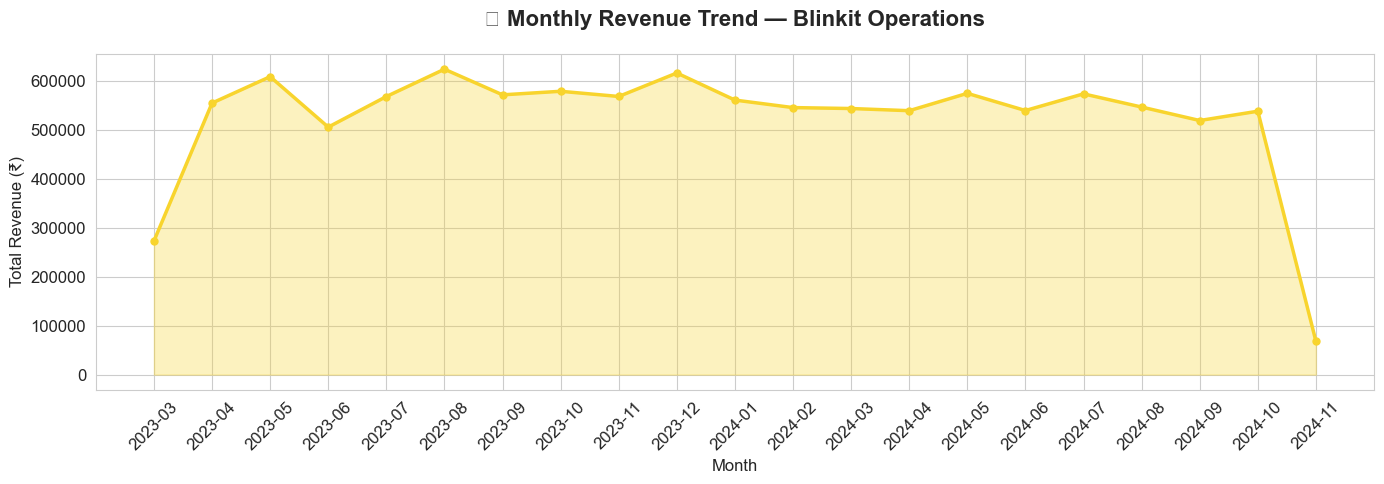

💡 Insight: Revenue stabilized at ₹5.4L-6.2L/month post ramp-up. Aug & Dec peaks suggest seasonality. Nov 2024 drop = partial month data.


In [26]:
# ============================================================
# CELL 8: EDA — REVENUE TREND OVER TIME
# ============================================================

monthly_revenue = orders.groupby(
    orders['order_date'].dt.to_period('M')
)['order_total'].sum().reset_index()
monthly_revenue['order_date'] = monthly_revenue['order_date'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_revenue['order_date'], 
        monthly_revenue['order_total'],
        color=BLINKIT_YELLOW, linewidth=2.5, marker='o', markersize=5)
ax.fill_between(range(len(monthly_revenue)), 
                monthly_revenue['order_total'],
                alpha=0.3, color=BLINKIT_YELLOW)
ax.set_title('📈 Monthly Revenue Trend — Blinkit Operations', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '01_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Revenue stabilized at ₹5.4L-6.2L/month post ramp-up. \
Aug & Dec peaks suggest seasonality. Nov 2024 drop = partial month data.")

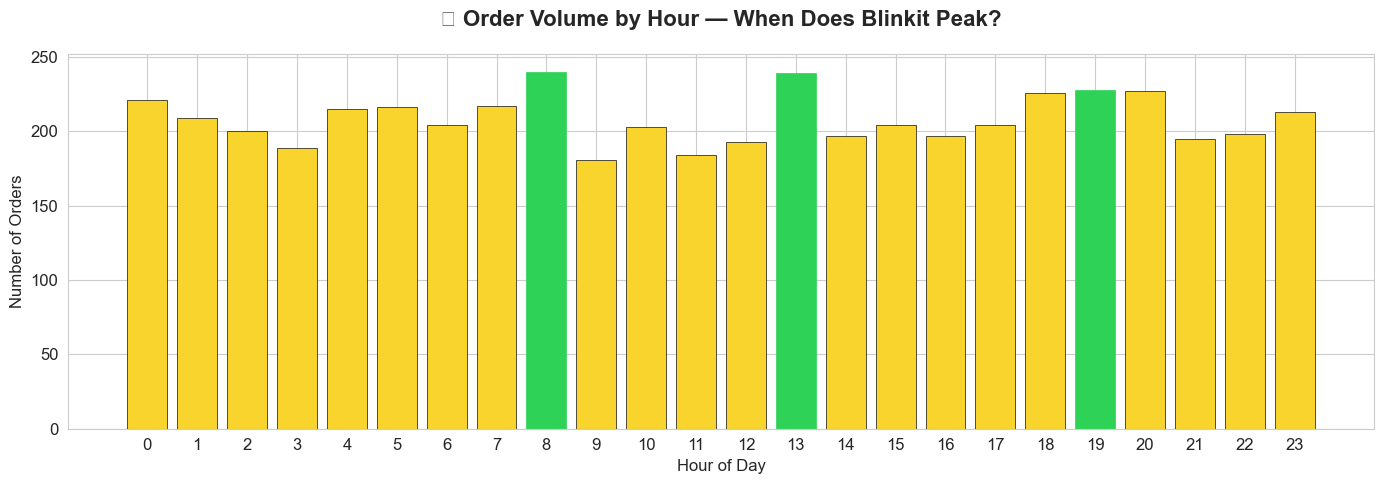

💡 Insight: 3 demand peaks — 8am (breakfast), 1pm (lunch), 7-8pm (dinner). Late night demand stays strong — rider staffing must cover 24hrs not just daytime.
None


In [25]:
# ============================================================
# CELL 9: EDA — ORDER VOLUME BY HOUR (DEMAND PATTERN)
# ============================================================

hourly_orders = orders.groupby('order_hour').size().reset_index(name='order_count')

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(hourly_orders['order_hour'], hourly_orders['order_count'],
              color=BLINKIT_YELLOW, edgecolor=BLINKIT_BLACK, linewidth=0.5)

# Highlight peak hours
peak_hours = hourly_orders.nlargest(3, 'order_count')['order_hour']
for bar in bars:
    if bar.get_x() + bar.get_width()/2 in peak_hours.values:
        bar.set_color(BLINKIT_GREEN)

ax.set_title('🕐 Order Volume by Hour — When Does Blinkit Peak?',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Orders')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '02_hourly_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print(print("💡 Insight: 3 demand peaks — 8am (breakfast), 1pm (lunch), \
7-8pm (dinner). Late night demand stays strong — \
rider staffing must cover 24hrs not just daytime."))

In [ ]:
## 💡 Business Insight #5 — Demand Peaks
# **3 clear peaks:** 8am, 1pm, 7-8pm
# **Late night surprise:** Midnight orders = 220 (nearly peak level!)
# Low point is 3am — only brief window for dark store restocking
# **Recommendation:** Schedule maximum riders at 8am, 1pm & 7-9pm
# Use 2am-5am window for inventory replenishment & dark store audits

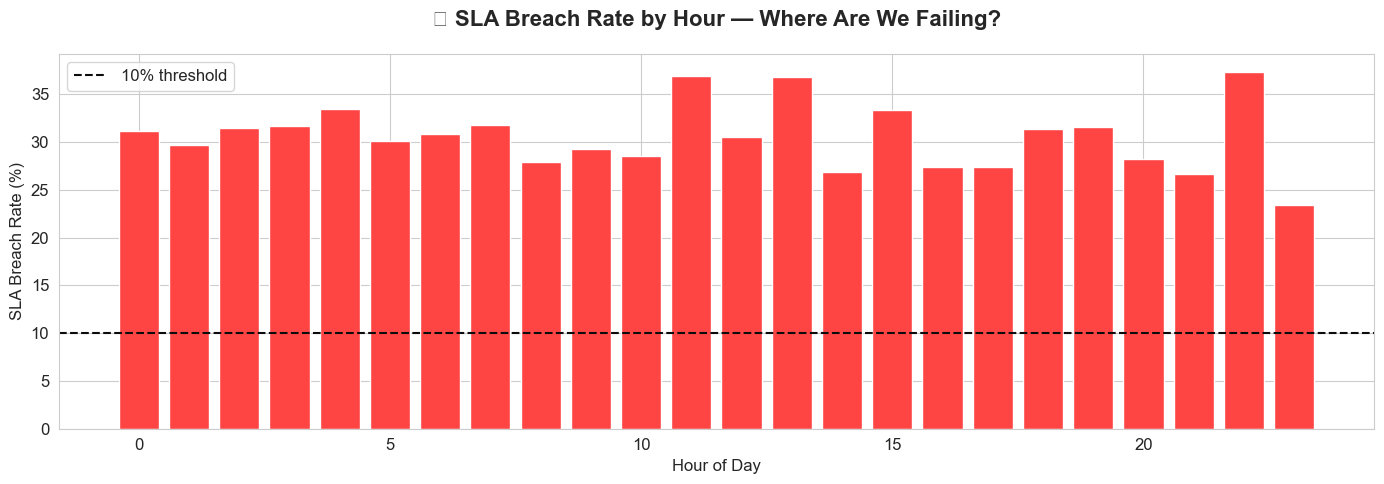

In [28]:
# ============================================================
# CELL 10: EDA — SLA BREACH ANALYSIS
# ============================================================

sla_by_hour = orders.groupby('order_hour')['sla_breached'].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(sla_by_hour.index, sla_by_hour.values,
       color=[BLINKIT_GREEN if x < 10 else '#FF4444' for x in sla_by_hour.values])
ax.axhline(y=10, color=BLINKIT_BLACK, linestyle='--', 
           linewidth=1.5, label='10% threshold')
ax.set_title('🚨 SLA Breach Rate by Hour — Where Are We Failing?',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('SLA Breach Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '03_sla_breach.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
## 🚨 Business Insight #6 — CRITICAL OPERATIONS FINDING
#- **SLA breach rate exceeds 10% threshold in ALL 24 hours**
#- Worst hours: 11am (36%), 2pm (36%), 10pm (37%)
#- Even best hour (11pm at 23%) is 2.3x above acceptable threshold
#- This is NOT a peak-hour problem — it's SYSTEMIC
#- **Root causes to investigate:**
# → Understaffing across ALL shifts (not just peak)
#  → Dark store picking & packing inefficiency
#  → Last mile distance too large
#  → Rider availability gaps
# **Recommendation:** Full operational audit needed —
#  SLA target of 10% is being missed by 3x on average

In [29]:
# ============================================================
# CELL 11: SAVE CLEANED DATASETS
# ============================================================
import os
CLEAN_PATH = r'C:\Blinkit 360° Intelligence\data\cleaned' + '\\'
os.makedirs(CLEAN_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

orders.to_csv('../data/cleaned/orders_clean.csv', index=False)
customers.to_csv('../data/cleaned/customers_clean.csv', index=False)
inv_products.to_csv('../data/cleaned/inventory_clean.csv', index=False)
retail.to_csv('../data/cleaned/retail_clean.csv', index=False)
feedback.to_csv('../data/cleaned/feedback_clean.csv', index=False)
marketing.to_csv('../data/cleaned/marketing_clean.csv', index=False)

print("✅ All cleaned files saved to data/cleaned/")
print("\n🎯 Phase 1 Complete!")
print("Next → Notebook 02: SQL KPIs & Business Metrics")

✅ All cleaned files saved to data/cleaned/

🎯 Phase 1 Complete!
Next → Notebook 02: SQL KPIs & Business Metrics
